In [1]:
import sys
src_path = "/home/souvik/codes/foresee-main"
sys.path.append(src_path)

import numpy as np
import os
from matplotlib import pyplot as plt
import math
import random
from skhep.math.vectors import LorentzVector, Vector3D
from scipy import interpolate
from matplotlib import gridspec
import os, inspect

In [2]:
from src_modified.foresee import Foresee, Utility, Model
foresee = Foresee()

energy = "14"
modelname="U1_llzplln_faser"
model = Model(modelname, path="./")

In [3]:
sys.path.insert(1, os.path.join(os.path.dirname(os.path.realpath(
                inspect.getfile(inspect.currentframe()))), "/home/souvik/codes/darkcast_chiral/"))
import darkcast 

In [4]:
model.add_production_2bodydecay(
    pid0 = "111",
    pid1 = "22",
    br = "2*0.99 * (coupling/0.303)**2 * pow(1.-pow(mass/self.masses('111'),2),3)",
#     br = "2*0.99 * (coupling)**2 * pow(1.-pow(mass/self.masses('111'),2),3)",
    generator = "EPOSLHC",
    energy = energy,
    nsample = 50,
)

model.add_production_2bodydecay(
    pid0 = "221",
    pid1 = "22",
    br = "2*0.25*0.39  * (coupling/0.303)**2 * pow(1.-pow(mass/self.masses('221'),2),3)",
#     br = "2*0.39 * (coupling)**2 * pow(1.-pow(mass/self.masses('221'),2),3)",
    generator = "EPOSLHC",
    energy = energy,
    nsample = 50, 
)

In [5]:
masses_brem = [ 
   0.01  ,  0.0126,  0.0158,  0.02  ,  0.0251,  0.0316,  0.0398,
   0.0501,  0.0631,  0.0794,  0.1   ,  0.1122,  0.1259,  0.1413,
   0.1585,  0.1778,  0.1995,  0.2239,  0.2512,  0.2818,  0.3162,
   0.3548,  0.3981,  0.4467,  0.5012,  0.5623,  0.6026,  0.631 ,
   0.6457,  0.6607,  0.6761,  0.6918,  0.7079,  0.7244,  0.7413,
   0.7586,  0.7762,  0.7943,  0.8128,  0.8318,  0.8511,  0.871 ,
   0.8913,  0.912 ,  0.9333,  0.955 ,  0.9772,  1.    ,  1.122 ,
   1.2589,  1.4125,  1.5849,  1.7783,  1.9953,  2.2387,  2.5119,
   2.8184,  3.1623,  3.9811,  5.0119,  6.3096,  7.9433, 10.    
]

model.add_production_direct(
    label = "Brem",
    energy = energy,
    condition = "1./0.3**2 * (p.pt<1)",
#     condition = "p.pt<1",
    coupling_ref=1,
    masses = masses_brem,
)

In [6]:
masses = np.logspace(-3, 1, 100)
masses = np.array(masses)
foresee.set_model(model=model)
# for mass in masses:
#     foresee.get_llp_spectrum(mass=mass, coupling=1, luminosity=3000, mincount=0,
#                                 do_plot=False, stat_cuts=None, save_file=True)

In [7]:
# model.set_ctau_1d( folder = "model/",
#     filename="ctau_RHN3.txt", xHs = [-2, -1, -0.5, 0, 0.5, 1, 2],
#     coupling_ref=1
# )
# branchings = [
#     ["e_e"     , "red"          , "solid" , r"ee"         , 0.050, 0.20],
#     ["mu_mu"   , "orange"       , "solid" , r"$\mu\mu$"   , 0.170, 0.10],
#     ["tau_tau"   , "orange"       , "solid" , r"$\mu\mu$"   , 1.8905, 0.10],

#     # ["nu_nu"   , "black"        , "dashed", r"$\nu\nu$"   , 0.110, 0.70],
#     ["hadrons" , "blue"         , "solid" , r"hadrons"    , 0.410, 0.02],
    
#     # ["rhn" , "brown"         , "solid" , r"rhn"    , 0.110, 0.35]
# ]

# model.set_br_1d(
#     modes=[channel for channel,_,_,_,_,_ in branchings],
#     finalstates=[[11,-11], [13,-13], [12,-12], None], folder = "model/br_RHN3/", xHs = [-2, -1, -0.5, 0, 0.5, 1, 2],
#     filenames=[channel+".txt" for channel,_,_,_,_,_ in branchings],
# )

In [9]:
%%time
distance, selection, length, luminosity, channels = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000, ["e_e", "mu_mu", "tau_tau", "hadrons"]
energy, setup, name = '14', "heavy", "U1_X"
foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, channels=channels, name=name)

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH=-2, model1="U1_X_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1000, mN2=1000, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH = -1.2, model1="U1_X_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1000, mN2=1000, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH = 0, model1="U1_X_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1000, mN2=1000, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH=2, model1="U1_X_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1000, mN2=1000, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

/home/souvik/codes/darkcast_chiral/darkcast/model.py:347: RuntimeWarning: divide by zero encountered in double_scalars
  return 1.97e-16/self.width("total", m, xH, g)


CPU times: user 14min 11s, sys: 8.33 s, total: 14min 20s
Wall time: 14min 20s


In [8]:
%%time
distance, selection, length, luminosity, channels = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000, ["e_e", "mu_mu", "tau_tau", "hadrons"]
energy, setup, name = '14', "default", "U1_X"
foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, channels=channels, name=name)

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH=-2, model1="U1_X_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1000, mN2=1/3, mN3=1/3)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH = -1.2, model1="U1_X_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH = 0, model1="U1_X_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH=2, model1="U1_X_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

/home/souvik/anaconda3/lib/python3.11/site-packages/numpy/lib/npyio.py:521: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


CPU times: user 7min 35s, sys: 4.73 s, total: 7min 40s
Wall time: 7min 40s


/tmp/ipykernel_23667/1719134068.py:22: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label=r"$M_{N_{1,2}}=M_{Z'}/3$")
/tmp/ipykernel_23667/1719134068.py:37: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label="Heavy RHN")


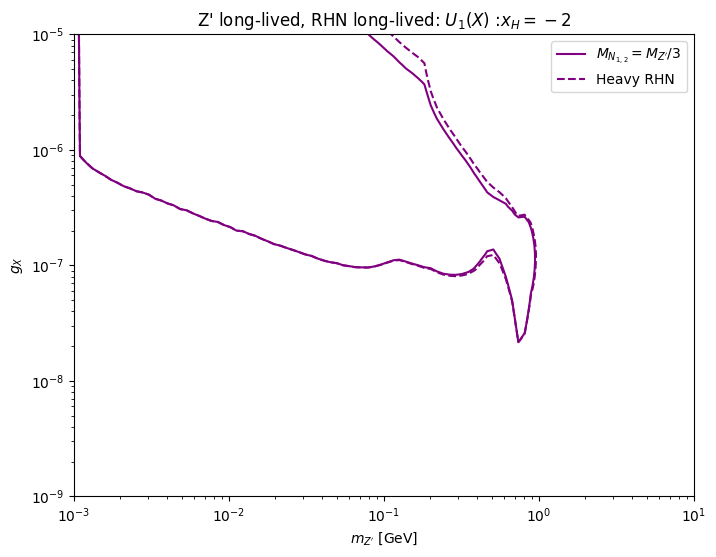

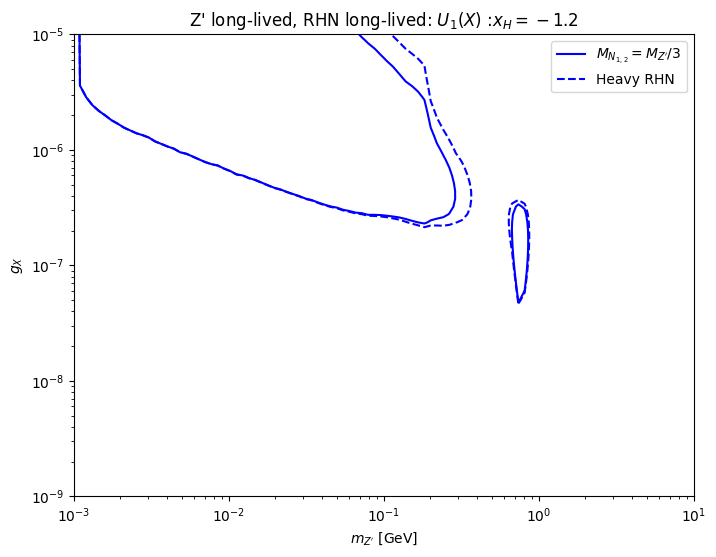

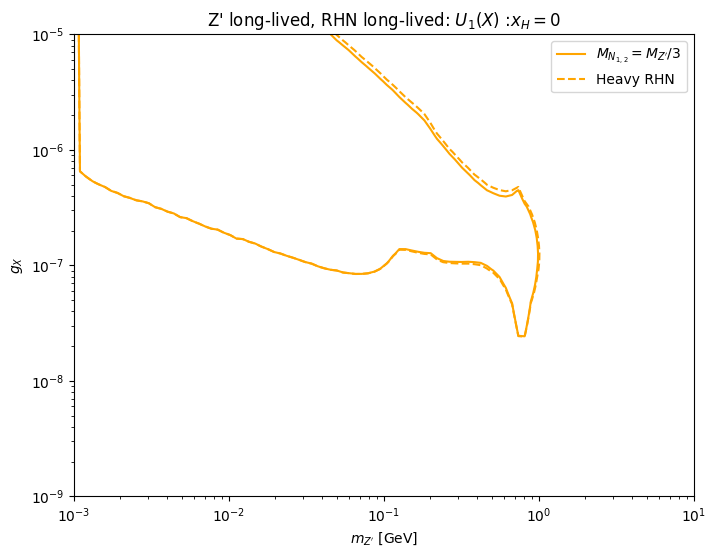

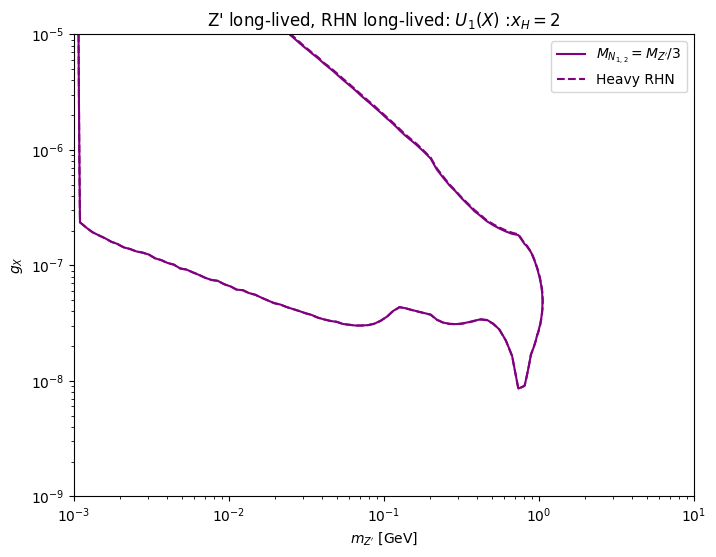

In [14]:
setups = [
         ["14TeV_default2n",    r"$x_H = -2$"  , "purple", "solid", 0., 3],#*150/3000],
         ["14TeV_default12n",    r"$x_H = -1.2$"  , "blue", "solid", 0., 3],#*150/3000],
         ["14TeV_default0",    r"$x_H = 0$"  , "orange", "solid", 0., 3],#*150/3000], 
         ["14TeV_default2p",    r"$x_H = 2$"  , "purple", "solid", 0., 3]#*150/3000]]
]
setupsH = [
         ["14TeV_heavy2n",    r"$x_H = -2$"  , "purple", "dashed", 0., 3],#*150/3000],
         ["14TeV_heavy12n",    r"$x_H = -1.2$"  , "blue", "dashed", 0., 3],#*150/3000],
         ["14TeV_heavy0",    r"$x_H = 0$"  , "orange", "dashed", 0., 3],#*150/3000],
         ["14TeV_heavy2p",    r"$x_H = 2$"  , "purple", "dashed", 0., 3]#*150/3000]]
]


for setup, setuph in zip(setups, setupsH):
    fig, ax = plt.subplots()
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3/"+filename+".npy", allow_pickle=True, encoding='latin1')
    # m, c, n = masses,couplings,nsignals #changed
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label=r"$M_{N_{1,2}}=M_{Z'}/3$")
    ax.plot([0],[0],label=r"$M_{N_{1,2}}=M_{Z'}/3$", color=color, linestyle=ls)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-9, 1e-5)
    
    filename, label, color, ls, alpha, level = setuph
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3/"+filename+".npy", allow_pickle=True, encoding='latin1')
    # m, c, n = masses,couplings,nsignals #changed
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label="Heavy RHN")
    ax.plot([0],[0],label="Heavy RHN", color=color, linestyle=ls)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-9, 1e-5)
    ax.legend()
    ax.set_title(r"Z' long-lived, RHN long-lived: $U_1(X)$ :"+label)
    plt.savefig(model.modelpath+"model/results_RHN3/plots/"+filename+".png")

In [10]:
# model.set_ctau_1d( folder = "model/",
#     filename="ctau_RHN3_phi4.txt", xHs = [-2, -1, -0.5, 0, 0.5, 1, 2],
#     coupling_ref=1
# )
# branchings = [
#     ["e_e"     , "red"          , "solid" , r"ee"         , 0.050, 0.20],
#     ["mu_mu"   , "orange"       , "solid" , r"$\mu\mu$"   , 0.170, 0.10],
#     ["tau_tau"   , "orange"       , "solid" , r"$\mu\mu$"   , 1.8905, 0.10],

#     ["nu_nu"   , "black"        , "dashed", r"$\nu\nu$"   , 0.110, 0.70],
#     ["hadrons" , "blue"         , "solid" , r"hadrons"    , 0.410, 0.02],
    
#     ["rhn" , "brown"         , "solid" , r"rhn"    , 0.110, 0.35]
# ]

# model.set_br_1d(
#     modes=[channel for channel,_,_,_,_,_ in branchings],
#     finalstates=[[11,-11], [13,-13], [12,-12], None, None,None], folder = "model/br_RHN3_phi4/", xHs = [-2, -1, -0.5, 0, 0.5, 1, 2],
#     filenames=[channel+".txt" for channel,_,_,_,_,_ in branchings],
# )

In [11]:
%%time
distance, selection, length, luminosity, channels = 620, "np.sqrt(x.x**2 + x.y**2)< 1", 10, 3000, ["e_e", "mu_mu", "tau_tau", "hadrons"]
energy, setup, name = '14', "alternative", "U1_X_phi4"
foresee.set_detector(distance=distance, selection=selection, length=length, luminosity=luminosity, channels=channels, name=name)

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH=-2, model1="U1_X_phi4_2n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"2n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH = -1.2, model1="U1_X_phi4_12n", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
        
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"12n.npy",[masses,couplings,list_nevents])


list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH = 0, model1="U1_X_phi4_0", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
    
#save results
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"0.npy",[masses,couplings,list_nevents])

#get reach  
list_nevents = []    
#masses = np.logspace(-2, 1, 50)
for mass in masses:
    couplings, _, nevents, _, _  = foresee.get_events(nsample=1, mass=mass, xH=2, model1="U1_X_phi4_2p", model0="B-L_boson", energy=energy,
                                    couplings = np.logspace(-9,-5,60), preselectioncuts="th<1/630",
                                                     mN1=1/3, mN2=1/3, mN3=1000)
    list_nevents.append(nevents)  
np.save("model/results_RHN3/"+energy+"TeV_"+setup+"2p.npy",[masses,couplings,list_nevents])

CPU times: user 20min 14s, sys: 9.13 s, total: 20min 23s
Wall time: 20min 25s


/tmp/ipykernel_23667/3306621740.py:22: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label=r"$M_{N_{1,2}}=M_{Z'}/3$")
/tmp/ipykernel_23667/3306621740.py:37: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label="Heavy RHN")


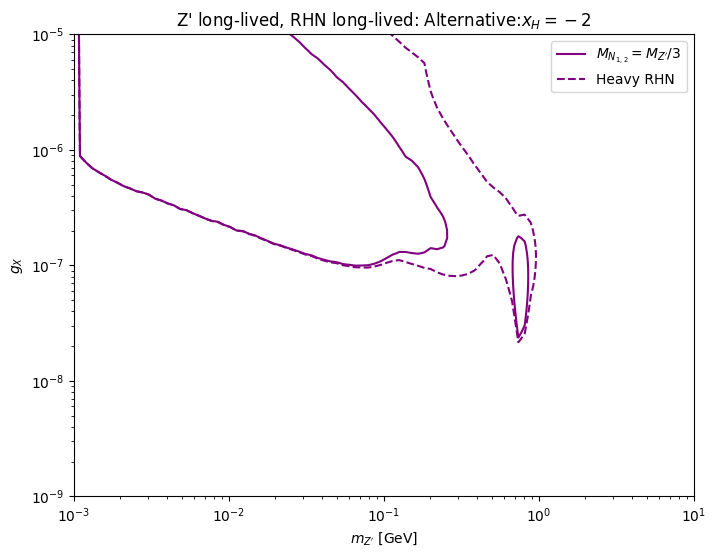

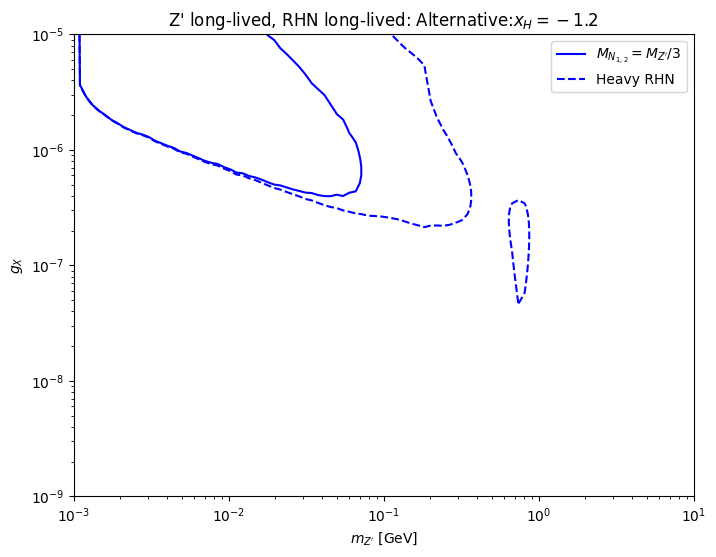

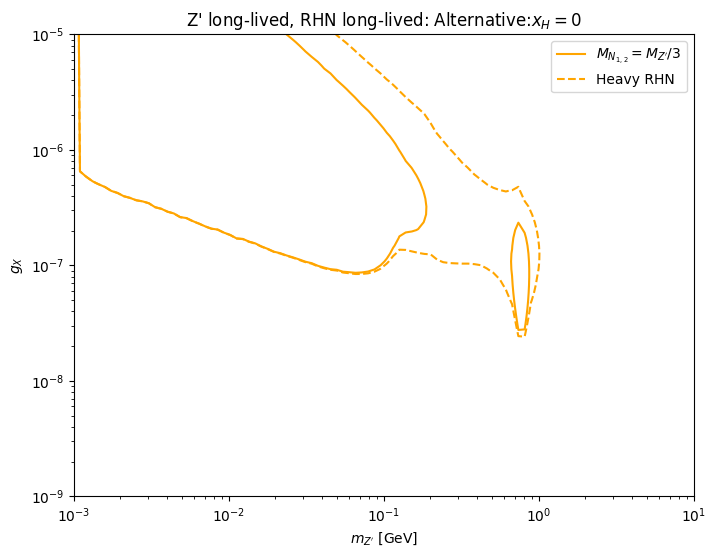

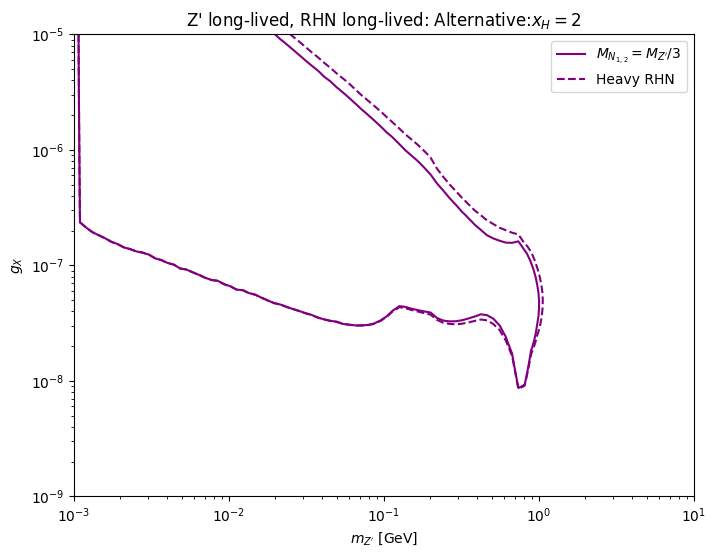

In [15]:
setups = [
         ["14TeV_alternative2n",    r"$x_H = -2$"  , "purple", "solid", 0., 3],#*150/3000],
         ["14TeV_alternative12n",    r"$x_H = -1.2$"  , "blue", "solid", 0., 3],#*150/3000],
         ["14TeV_alternative0",    r"$x_H = 0$"  , "orange", "solid", 0., 3],#*150/3000], 
         ["14TeV_alternative2p",    r"$x_H = 2$"  , "purple", "solid", 0., 3]#*150/3000]]
]
setupsH = [
         ["14TeV_heavy2n",    r"$x_H = -2$"  , "purple", "dashed", 0., 3],#*150/3000],
         ["14TeV_heavy12n",    r"$x_H = -1.2$"  , "blue", "dashed", 0., 3],#*150/3000],
         ["14TeV_heavy0",    r"$x_H = 0$"  , "orange", "dashed", 0., 3],#*150/3000],
         ["14TeV_heavy2p",    r"$x_H = 2$"  , "purple", "dashed", 0., 3]#*150/3000]]
]


for setup, setuph in zip(setups, setupsH):
    fig, ax = plt.subplots()
    filename, label, color, ls, alpha, level = setup
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3/"+filename+".npy", allow_pickle=True, encoding='latin1')
    # m, c, n = masses,couplings,nsignals #changed
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label=r"$M_{N_{1,2}}=M_{Z'}/3$")
    ax.plot([0],[0],label=r"$M_{N_{1,2}}=M_{Z'}/3$", color=color, linestyle=ls)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-9, 1e-5)
    
    filename, label, color, ls, alpha, level = setuph
    masses,couplings,nsignals=np.load(model.modelpath+"model/results_RHN3/"+filename+".npy", allow_pickle=True, encoding='latin1')
    # m, c, n = masses,couplings,nsignals #changed
    m, c = np.meshgrid(masses, couplings)
    n = np.log10(np.array(nsignals).T+1e-20)
    ax.contour (m,c,n, levels=[np.log10(level)],colors=color, linestyles=ls, label="Heavy RHN")
    ax.plot([0],[0],label="Heavy RHN", color=color, linestyle=ls)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$m_{Z'}$ [GeV]") 
    ax.set_ylabel(r"$g_X$")
    plt.rcParams["figure.figsize"]=(8,6)
    ax.set_xlim(1e-3, 10)
    ax.set_ylim(1e-9, 1e-5)
    ax.legend()
    ax.set_title(r"Z' long-lived, RHN long-lived: Alternative:"+label)
    plt.savefig(model.modelpath+"model/results_RHN3/plots/"+filename+".png")